# 10 Minutes to pandas

This is a short introduction to pandas, geared mainly for new users. You can see more complex recipes in the [Cookbook](https://pandas.pydata.org/pandas-docs/stable/user_guide/cookbook.html).

https://pandas.pydata.org/pandas-docs/stable/user_guide/10min.html

In [1]:
import numpy as np
import pandas as pd

## Basic data structures in pandas

pandas provides two types of classes for handling data:

1. **`Series`**: a one-dimensional labeled array holding data of any type such as integers, strings, Python objects, etc.
2. **`DataFrame`**: a two-dimensional data structure that holds data like a two-dimensional array or a table with rows and columns.

## Object creation

See the [Intro to data structures section](https://pandas.pydata.org/pandas-docs/stable/user_guide/dsintro.html).

Creating a `Series` by passing a list of values, letting pandas create a default `RangeIndex`:

In [2]:
s = pd.Series([1, 3, 5, np.nan, 6, 8])
s

0    1.0
1    3.0
2    5.0
3    NaN
4    6.0
5    8.0
dtype: float64

Creating a `DataFrame` by passing a NumPy array with a datetime index using `date_range()` and labeled columns:

In [3]:
dates = pd.date_range("20130101", periods=6)
dates

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [4]:
df = pd.DataFrame(np.random.randn(6, 4), index=dates, columns=list("ABCD"))
df

,A,B,C,D
2013-01-01,-0.830958,-0.738621,-1.235833,-0.141579
2013-01-02,0.275414,0.451937,0.234370,-1.078426
2013-01-03,-2.060394,0.673043,-1.001775,-0.091790
2013-01-04,0.713782,1.668986,1.114992,0.876646
2013-01-05,0.199181,-0.438048,0.229062,1.635856
2013-01-06,-0.021121,1.474235,1.675444,3.329173


Creating a `DataFrame` by passing a dictionary of objects where the keys are the column labels and the values are the column values:

In [5]:
df2 = pd.DataFrame(
    {
        "A": 1.0,
        "B": pd.Timestamp("20130102"),
        "C": pd.Series(1, index=list(range(4)), dtype="float32"),
        "D": np.array([3] * 4, dtype="int32"),
        "E": pd.Categorical(["test", "train", "test", "train"]),
        "F": "foo",
    }
)
df2

,A,B,C,D,E,F
0,1.0,2013-01-02,1.0,3,test,foo
1,1.0,2013-01-02,1.0,3,train,foo
2,1.0,2013-01-02,1.0,3,test,foo
3,1.0,2013-01-02,1.0,3,train,foo


The columns of the resulting `DataFrame` have different dtypes:

In [6]:
df2.dtypes

A          float64
B    datetime64[s]
C          float32
D            int32
E         category
F           object
dtype: object

## Viewing data

See the [Essential basic functionality section](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html).

Use `DataFrame.head()` and `DataFrame.tail()` to view the top and bottom rows of the frame respectively:

In [7]:
df.head()

,A,B,C,D
2013-01-01,-0.830958,-0.738621,-1.235833,-0.141579
2013-01-02,0.275414,0.451937,0.234370,-1.078426
2013-01-03,-2.060394,0.673043,-1.001775,-0.091790
2013-01-04,0.713782,1.668986,1.114992,0.876646
2013-01-05,0.199181,-0.438048,0.229062,1.635856


In [8]:
df.tail(3)

,A,B,C,D
2013-01-04,0.713782,1.668986,1.114992,0.876646
2013-01-05,0.199181,-0.438048,0.229062,1.635856
2013-01-06,-0.021121,1.474235,1.675444,3.329173


Display the `DataFrame.index` or `DataFrame.columns`:

In [9]:
df.index

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06'],
              dtype='datetime64[ns]', freq='D')

In [10]:
df.columns

Index(['A', 'B', 'C', 'D'], dtype='object')

Return a NumPy representation of the underlying data with `DataFrame.to_numpy()` without the index or column labels:

In [11]:
df.to_numpy()

array([[-0.83095804, -0.73862095, -1.23583264, -0.14157882],
       [ 0.27541389,  0.45193688,  0.23437001, -1.07842589],
       [-2.06039444,  0.6730431 , -1.00177504, -0.09179043],
       [ 0.71378161,  1.66898625,  1.11499152,  0.87664566],
       [ 0.19918053, -0.43804756,  0.2290616 ,  1.63585607],
       [-0.02112127,  1.47423451,  1.67544396,  3.32917282]])

> **Note:** NumPy arrays have one dtype for the entire array while pandas DataFrames have one dtype per column. When you call `DataFrame.to_numpy()`, pandas will find the NumPy dtype that can hold *all* of the dtypes in the DataFrame. If the common data type is `object`, `DataFrame.to_numpy()` will require copying data.

In [12]:
df2.to_numpy()

array([[1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'train', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'test', 'foo'],
       [1.0, Timestamp('2013-01-02 00:00:00'), 1.0, 3, 'train', 'foo']],
      dtype=object)

`describe()` shows a quick statistic summary of your data:

In [13]:
df.describe()

,A,B,C,D
count,6.000000,6.000000,6.000000,6.000000
mean,-0.287350,0.515255,0.169377,0.754980
std,1.006554,0.975770,1.141615,1.568402
min,-2.060394,-0.738621,-1.235833,-1.078426
25%,-0.628499,-0.215551,-0.694066,-0.129132
50%,0.089030,0.562490,0.231716,0.392428
75%,0.256356,1.273937,0.894836,1.446053
max,0.713782,1.668986,1.675444,3.329173


Transposing your data:

In [14]:
df.T

,2013-01-01,2013-01-02,2013-01-03,2013-01-04,2013-01-05,2013-01-06
A,-0.830958,0.275414,-2.060394,0.713782,0.199181,-0.021121
B,-0.738621,0.451937,0.673043,1.668986,-0.438048,1.474235
C,-1.235833,0.234370,-1.001775,1.114992,0.229062,1.675444
D,-0.141579,-1.078426,-0.091790,0.876646,1.635856,3.329173


`DataFrame.sort_index()` sorts by an axis:

In [15]:
df.sort_index(axis=1, ascending=False)

,D,C,B,A
2013-01-01,-0.141579,-1.235833,-0.738621,-0.830958
2013-01-02,-1.078426,0.234370,0.451937,0.275414
2013-01-03,-0.091790,-1.001775,0.673043,-2.060394
2013-01-04,0.876646,1.114992,1.668986,0.713782
2013-01-05,1.635856,0.229062,-0.438048,0.199181
2013-01-06,3.329173,1.675444,1.474235,-0.021121


`DataFrame.sort_values()` sorts by values:

In [16]:
df.sort_values(by="B")

,A,B,C,D
2013-01-01,-0.830958,-0.738621,-1.235833,-0.141579
2013-01-05,0.199181,-0.438048,0.229062,1.635856
2013-01-02,0.275414,0.451937,0.234370,-1.078426
2013-01-03,-2.060394,0.673043,-1.001775,-0.091790
2013-01-06,-0.021121,1.474235,1.675444,3.329173
2013-01-04,0.713782,1.668986,1.114992,0.876646


## Selection

> **Note:** While standard Python / NumPy expressions for selecting and setting are intuitive and come in handy for interactive work, for production code, we recommend the optimized pandas data access methods: `DataFrame.at()`, `DataFrame.iat()`, `DataFrame.loc()` and `DataFrame.iloc()`.

See the indexing documentation [Indexing and Selecting Data](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html) and [MultiIndex / Advanced Indexing](https://pandas.pydata.org/pandas-docs/stable/user_guide/advanced.html).

### Getitem (`[]`)

For a `DataFrame`, passing a single label selects a column and yields a `Series`:

In [17]:
df["A"]

2013-01-01   -0.830958
2013-01-02    0.275414
2013-01-03   -2.060394
2013-01-04    0.713782
2013-01-05    0.199181
2013-01-06   -0.021121
Freq: D, Name: A, dtype: float64

Passing a list of column labels selects multiple columns:

In [18]:
df[["B", "A"]]

,B,A
2013-01-01,-0.738621,-0.830958
2013-01-02,0.451937,0.275414
2013-01-03,0.673043,-2.060394
2013-01-04,1.668986,0.713782
2013-01-05,-0.438048,0.199181
2013-01-06,1.474235,-0.021121


For a `DataFrame`, passing a slice `:` selects matching rows:

In [19]:
df[0:3]

,A,B,C,D
2013-01-01,-0.830958,-0.738621,-1.235833,-0.141579
2013-01-02,0.275414,0.451937,0.234370,-1.078426
2013-01-03,-2.060394,0.673043,-1.001775,-0.091790


In [22]:
df["20130102":"20130104"]

,A,B,C,D
2013-01-02,0.275414,0.451937,0.234370,-1.078426
2013-01-03,-2.060394,0.673043,-1.001775,-0.091790
2013-01-04,0.713782,1.668986,1.114992,0.876646


### Selection by label

See more in [Selection by Label](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#selection-by-label) using `DataFrame.loc()` or `DataFrame.at()`.

Selecting a row matching a label:

In [24]:
df.loc[dates[0]]

A   -0.830958
B   -0.738621
C   -1.235833
D   -0.141579
Name: 2013-01-01 00:00:00, dtype: float64

Selecting all rows (`:`) with select column labels:

In [25]:
df.loc[:, ["A", "B"]]

,A,B
2013-01-01,-0.830958,-0.738621
2013-01-02,0.275414,0.451937
2013-01-03,-2.060394,0.673043
2013-01-04,0.713782,1.668986
2013-01-05,0.199181,-0.438048
2013-01-06,-0.021121,1.474235


For label slicing, both endpoints are *included*:

In [26]:
df.loc["20130102":"20130104", ["A", "B"]]

,A,B
2013-01-02,0.275414,0.451937
2013-01-03,-2.060394,0.673043
2013-01-04,0.713782,1.668986


Selecting a single row and column label returns a scalar:

In [27]:
df.loc[dates[0], "A"]

-0.8309580448617664

For getting fast access to a scalar (equivalent to the prior method):

In [28]:
df.at[dates[0], "A"]

-0.8309580448617664

### Selection by position

See more in [Selection by Position](https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#selection-by-position) using `DataFrame.iloc()` or `DataFrame.iat()`.

Select via the position of the passed integers:

In [29]:
df.iloc[3]

A    0.713782
B    1.668986
C    1.114992
D    0.876646
Name: 2013-01-04 00:00:00, dtype: float64

Integer slices act similarly to NumPy/Python:

In [30]:
df.iloc[3:5, 0:2]

,A,B
2013-01-04,0.713782,1.668986
2013-01-05,0.199181,-0.438048


Lists of integer position locations:

In [31]:
df.iloc[[1, 2, 4], [0, 2]]

,A,C
2013-01-02,0.275414,0.234370
2013-01-03,-2.060394,-1.001775
2013-01-05,0.199181,0.229062


For slicing rows explicitly:

In [32]:
df.iloc[1:3, :]

,A,B,C,D
2013-01-02,0.275414,0.451937,0.234370,-1.078426
2013-01-03,-2.060394,0.673043,-1.001775,-0.091790


For slicing columns explicitly:

In [33]:
df.iloc[:, 1:3]

,B,C
2013-01-01,-0.738621,-1.235833
2013-01-02,0.451937,0.234370
2013-01-03,0.673043,-1.001775
2013-01-04,1.668986,1.114992
2013-01-05,-0.438048,0.229062
2013-01-06,1.474235,1.675444


For getting a value explicitly:

In [34]:
df.iloc[1, 1]

0.45193687996591275

For getting fast access to a scalar (equivalent to the prior method):

In [35]:
df.iat[1, 1]

0.45193687996591275

### Boolean indexing

Select rows where `df.A` is greater than `0`:

In [36]:
df[df["A"] > 0]

,A,B,C,D
2013-01-02,0.275414,0.451937,0.234370,-1.078426
2013-01-04,0.713782,1.668986,1.114992,0.876646
2013-01-05,0.199181,-0.438048,0.229062,1.635856


Selecting values from a `DataFrame` where a boolean condition is met:

In [37]:
df[df > 0]

,A,B,C,D
2013-01-01,NaN,NaN,NaN,NaN
2013-01-02,0.275414,0.451937,0.234370,NaN
2013-01-03,NaN,0.673043,NaN,NaN
2013-01-04,0.713782,1.668986,1.114992,0.876646
2013-01-05,0.199181,NaN,0.229062,1.635856
2013-01-06,NaN,1.474235,1.675444,3.329173


Using `isin()` method for filtering:

In [38]:
df2 = df.copy()
df2["E"] = ["one", "one", "two", "three", "four", "three"]
df2

,A,B,C,D,E
2013-01-01,-0.830958,-0.738621,-1.235833,-0.141579,one
2013-01-02,0.275414,0.451937,0.234370,-1.078426,one
2013-01-03,-2.060394,0.673043,-1.001775,-0.091790,two
2013-01-04,0.713782,1.668986,1.114992,0.876646,three
2013-01-05,0.199181,-0.438048,0.229062,1.635856,four
2013-01-06,-0.021121,1.474235,1.675444,3.329173,three


In [39]:
df2[df2["E"].isin(["two", "four"])]

,A,B,C,D,E
2013-01-03,-2.060394,0.673043,-1.001775,-0.091790,two
2013-01-05,0.199181,-0.438048,0.229062,1.635856,four


### Setting

Setting a new column automatically aligns the data by the indexes:

In [40]:
s1 = pd.Series([1, 2, 3, 4, 5, 6], index=pd.date_range("20130102", periods=6))
s1

2013-01-02    1
2013-01-03    2
2013-01-04    3
2013-01-05    4
2013-01-06    5
2013-01-07    6
Freq: D, dtype: int64

In [41]:
df["F"] = s1

Setting values by label:

In [42]:
df.at[dates[0], "A"] = 0

Setting values by position:

In [43]:
df.iat[0, 1] = 0

Setting by assigning with a NumPy array:

In [44]:
df.loc[:, "D"] = np.array([5] * len(df))

The result of the prior setting operations:

In [45]:
df

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-1.235833,5.0,NaN
2013-01-02,0.275414,0.451937,0.234370,5.0,1.0
2013-01-03,-2.060394,0.673043,-1.001775,5.0,2.0
2013-01-04,0.713782,1.668986,1.114992,5.0,3.0
2013-01-05,0.199181,-0.438048,0.229062,5.0,4.0
2013-01-06,-0.021121,1.474235,1.675444,5.0,5.0


A `where` operation with setting:

In [46]:
df2 = df.copy()
df2[df2 > 0] = -df2
df2

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-1.235833,-5.0,NaN
2013-01-02,-0.275414,-0.451937,-0.234370,-5.0,-1.0
2013-01-03,-2.060394,-0.673043,-1.001775,-5.0,-2.0
2013-01-04,-0.713782,-1.668986,-1.114992,-5.0,-3.0
2013-01-05,-0.199181,-0.438048,-0.229062,-5.0,-4.0
2013-01-06,-0.021121,-1.474235,-1.675444,-5.0,-5.0


## Missing data

For NumPy data types, `np.nan` represents missing data. It is by default not included in computations. See the [Missing Data section](https://pandas.pydata.org/pandas-docs/stable/user_guide/missing_data.html).

Reindexing allows you to change/add/delete the index on a specified axis. This returns a copy of the data:

In [47]:
df1 = df.reindex(index=dates[0:4], columns=list(df.columns) + ["E"])
df1.loc[dates[0] : dates[1], "E"] = 1
df1

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,-1.235833,5.0,NaN,1.0
2013-01-02,0.275414,0.451937,0.234370,5.0,1.0,1.0
2013-01-03,-2.060394,0.673043,-1.001775,5.0,2.0,NaN
2013-01-04,0.713782,1.668986,1.114992,5.0,3.0,NaN


`DataFrame.dropna()` drops any rows that have missing data:

In [52]:
df1.dropna(subset=["F"], how="any")

,A,B,C,D,F,E
2013-01-02,0.275414,0.451937,0.234370,5.0,1.0,1.0
2013-01-03,-2.060394,0.673043,-1.001775,5.0,2.0,NaN
2013-01-04,0.713782,1.668986,1.114992,5.0,3.0,NaN


In [48]:
df1.dropna(how="any")

,A,B,C,D,F,E
2013-01-02,0.275414,0.451937,0.23437,5.0,1.0,1.0


`DataFrame.fillna()` fills missing data:

In [49]:
df1.fillna(value=5)

,A,B,C,D,F,E
2013-01-01,0.000000,0.000000,-1.235833,5.0,5.0,1.0
2013-01-02,0.275414,0.451937,0.234370,5.0,1.0,1.0
2013-01-03,-2.060394,0.673043,-1.001775,5.0,2.0,5.0
2013-01-04,0.713782,1.668986,1.114992,5.0,3.0,5.0


`isna()` gets the boolean mask where values are `nan`:

In [50]:
pd.isna(df1)

,A,B,C,D,F,E
2013-01-01,False,False,False,False,True,False
2013-01-02,False,False,False,False,False,False
2013-01-03,False,False,False,False,False,True
2013-01-04,False,False,False,False,False,True


## Operations

See the [Basic section on Binary Ops](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html#flexible-binary-operations).

### Stats

Operations in general *exclude* missing data.

Calculate the mean value for each column:

In [53]:
df.mean()

A   -0.148857
B    0.638359
C    0.169377
D    5.000000
F    3.000000
dtype: float64

Calculate the mean value for each row:

In [54]:
df.mean(axis=1)

2013-01-01    0.941042
2013-01-02    1.392344
2013-01-03    0.922175
2013-01-04    2.299552
2013-01-05    1.798039
2013-01-06    2.625711
Freq: D, dtype: float64

Operating with another `Series` or `DataFrame` with a different index or column will align the result with the union of the index or column labels. pandas automatically broadcasts along the specified dimension and fills unaligned labels with `np.nan`.

In [55]:
s = pd.Series([1, 3, 5, np.nan, 6, 8], index=dates).shift(2)
s

2013-01-01    NaN
2013-01-02    NaN
2013-01-03    1.0
2013-01-04    3.0
2013-01-05    5.0
2013-01-06    NaN
Freq: D, dtype: float64

In [56]:
df.sub(s, axis="index")

,A,B,C,D,F
2013-01-01,NaN,NaN,NaN,NaN,NaN
2013-01-02,NaN,NaN,NaN,NaN,NaN
2013-01-03,-3.060394,-0.326957,-2.001775,4.0,1.0
2013-01-04,-2.286218,-1.331014,-1.885008,2.0,0.0
2013-01-05,-4.800819,-5.438048,-4.770938,0.0,-1.0
2013-01-06,NaN,NaN,NaN,NaN,NaN


### User defined functions

`DataFrame.agg()` and `DataFrame.transform()` apply a user-defined function that reduces or broadcasts its result respectively:

In [57]:
df.agg(lambda x: np.mean(x) * 5.6)

A    -0.833597
B     3.574810
C     0.948509
D    28.000000
F    16.800000
dtype: float64

In [58]:
df.transform(lambda x: x * 101.2)

,A,B,C,D,F
2013-01-01,0.000000,0.000000,-125.066263,506.0,NaN
2013-01-02,27.871886,45.736012,23.718245,506.0,101.2
2013-01-03,-208.511918,68.111962,-101.379634,506.0,202.4
2013-01-04,72.234699,168.901408,112.837142,506.0,303.6
2013-01-05,20.157070,-44.330413,23.181034,506.0,404.8
2013-01-06,-2.137472,149.192533,169.554929,506.0,506.0


### Value Counts

See more at [Histogramming and Discretization](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html#histogramming-and-discretization).

In [59]:
s = pd.Series(np.random.randint(0, 7, size=10))
s

0    5
1    6
2    4
3    6
4    5
5    2
6    4
7    4
8    0
9    4
dtype: int64

In [60]:
s.value_counts()

4    4
5    2
6    2
2    1
0    1
Name: count, dtype: int64

<Axes: >

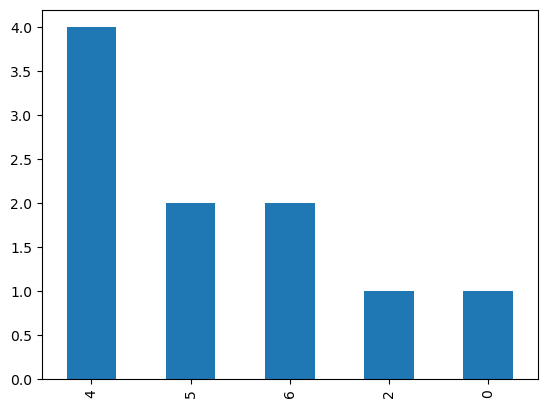

In [61]:
s.value_counts().plot.bar()

### String Methods

`Series` is equipped with a set of string processing methods in the `str` attribute that make it easy to operate on each element of the array. See more at [Vectorized String Methods](https://pandas.pydata.org/pandas-docs/stable/user_guide/text.html#string-methods).

In [62]:
s = pd.Series(["A", "B", "C", "Aaba", "Baca", np.nan, "CABA", "dog", "cat"])
s.str.lower()

0       a
1       b
2       c
3    aaba
4    baca
5     NaN
6    caba
7     dog
8     cat
dtype: object

## Merge

### Concat

pandas provides various facilities for easily combining together `Series` and `DataFrame` objects with various kinds of set logic for the indexes and relational algebra functionality in the case of join/merge-type operations.

See the [Merging section](https://pandas.pydata.org/pandas-docs/stable/user_guide/merging.html).

Concatenating pandas objects together row-wise with `concat()`:

In [63]:
df = pd.DataFrame(np.random.randn(10, 4))
df

,0,1,2,3
0,0.639820,-2.256683,-0.605889,1.436283
1,1.243169,0.218479,0.657271,0.758789
2,-1.319929,0.389774,-0.425828,-1.272401
3,-1.265284,-1.409827,1.268986,0.738190
4,-0.713524,-1.914659,0.920516,0.998616
5,-0.498525,0.397836,0.521725,0.598562
6,-0.102641,-1.225753,2.050541,-2.182211
7,-1.223932,0.800768,-0.049063,-2.079848
8,0.080586,0.154242,0.303803,0.069847
9,-1.132473,-0.452782,1.228382,-0.653259


In [64]:
# Break it into pieces
pieces = [df[:3], df[3:7], df[7:]]
pd.concat(pieces)

,0,1,2,3
0,0.639820,-2.256683,-0.605889,1.436283
1,1.243169,0.218479,0.657271,0.758789
2,-1.319929,0.389774,-0.425828,-1.272401
3,-1.265284,-1.409827,1.268986,0.738190
4,-0.713524,-1.914659,0.920516,0.998616
5,-0.498525,0.397836,0.521725,0.598562
6,-0.102641,-1.225753,2.050541,-2.182211
7,-1.223932,0.800768,-0.049063,-2.079848
8,0.080586,0.154242,0.303803,0.069847
9,-1.132473,-0.452782,1.228382,-0.653259


> **Note:** Adding a column to a `DataFrame` is relatively fast. However, adding a row requires a copy, and may be expensive. We recommend passing a pre-built list of records to the `DataFrame` constructor instead of building a `DataFrame` by iteratively appending records to it.

### Join

`merge()` enables SQL-style join types along specific columns. See the [Database style joining](https://pandas.pydata.org/pandas-docs/stable/user_guide/merging.html#database-style-dataframe-or-named-series-joining-merging) section.

In [66]:
left = pd.DataFrame({"key": ["foo", "foo"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "foo"], "rval": [4, 5]})
display(left)
display(right)

,key,lval
0,foo,1
1,foo,2


,key,rval
0,foo,4
1,foo,5


In [67]:
pd.merge(left, right, on="key")

,key,lval,rval
0,foo,1,4
1,foo,1,5
2,foo,2,4
3,foo,2,5


`merge()` on unique keys:

In [68]:
left = pd.DataFrame({"key": ["foo", "bar"], "lval": [1, 2]})
right = pd.DataFrame({"key": ["foo", "bar"], "rval": [4, 5]})
display(left)
display(right)
pd.merge(left, right, on="key")

,key,lval
0,foo,1
1,bar,2


,key,rval
0,foo,4
1,bar,5


,key,lval,rval
0,foo,1,4
1,bar,2,5


## Grouping

By "group by" we are referring to a process involving one or more of the following steps:

- **Splitting** the data into groups based on some criteria
- **Applying** a function to each group independently
- **Combining** the results into a data structure

See the [Grouping section](https://pandas.pydata.org/pandas-docs/stable/user_guide/groupby.html).

In [69]:
df = pd.DataFrame(
    {
        "A": ["foo", "bar", "foo", "bar", "foo", "bar", "foo", "foo"],
        "B": ["one", "one", "two", "three", "two", "two", "one", "three"],
        "C": np.random.randn(8),
        "D": np.random.randn(8),
    }
)
df

,A,B,C,D
0,foo,one,-0.627609,0.995294
1,bar,one,0.368590,-0.800959
2,foo,two,-0.643325,-1.082646
3,bar,three,-1.607696,1.539191
4,foo,two,0.510371,-0.238688
5,bar,two,-0.374011,-0.334487
6,foo,one,-1.184134,-0.691048
7,foo,three,0.572950,0.420891


Grouping by a column label, selecting column labels, and then applying the `DataFrameGroupBy.sum()` function to the resulting groups:

In [70]:
df.groupby("A")[["C", "D"]].sum()

,C,D
A,,
bar,-1.613117,0.403745
foo,-1.371747,-0.596197


Grouping by multiple columns forms a `MultiIndex`:

In [71]:
df.groupby(["A", "B"]).sum()

C         D
A   B                        
bar one    0.368590 -0.800959
    three -1.607696  1.539191
    two   -0.374011 -0.334487
foo one   -1.811742  0.304246
    three  0.572950  0.420891
    two   -0.132954 -1.321334

## Reshaping

See the sections on [Hierarchical Indexing](https://pandas.pydata.org/pandas-docs/stable/user_guide/advanced.html#hierarchical-indexing-multiindex) and [Reshaping](https://pandas.pydata.org/pandas-docs/stable/user_guide/reshaping.html).

### Stack

In [72]:
arrays = [
    ["bar", "bar", "baz", "baz", "foo", "foo", "qux", "qux"],
    ["one", "two", "one", "two", "one", "two", "one", "two"],
]
index = pd.MultiIndex.from_arrays(arrays, names=["first", "second"])
df = pd.DataFrame(np.random.randn(8, 2), index=index, columns=["A", "B"])
df2 = df[:4]
df2

A         B
first second                    
bar   one     0.525679 -0.666390
      two     0.011933  0.297947
baz   one    -1.614804 -0.972377
      two     2.030061  1.040015

The `stack()` method "compresses" a level in the DataFrame's columns:

In [73]:
stacked = df2.stack()
stacked

first  second   
bar    one     A    0.525679
               B   -0.666390
       two     A    0.011933
               B    0.297947
baz    one     A   -1.614804
               B   -0.972377
       two     A    2.030061
               B    1.040015
dtype: float64

With a "stacked" DataFrame or Series (having a `MultiIndex` as the `index`), the inverse operation of `stack()` is `unstack()`, which by default unstacks the **last level**:

In [74]:
stacked.unstack()

A         B
first second                    
bar   one     0.525679 -0.666390
      two     0.011933  0.297947
baz   one    -1.614804 -0.972377
      two     2.030061  1.040015

In [75]:
stacked.unstack(1)

second        one       two
first                      
bar   A  0.525679  0.011933
      B -0.666390  0.297947
baz   A -1.614804  2.030061
      B -0.972377  1.040015

In [76]:
stacked.unstack(0)

first          bar       baz
second                      
one    A  0.525679 -1.614804
       B -0.666390 -0.972377
two    A  0.011933  2.030061
       B  0.297947  1.040015

### Pivot tables

See the section on [Pivot Tables](https://pandas.pydata.org/pandas-docs/stable/user_guide/reshaping.html#pivot-tables).

In [77]:
df = pd.DataFrame(
    {
        "A": ["one", "one", "two", "three"] * 3,
        "B": ["A", "B", "C"] * 4,
        "C": ["foo", "foo", "foo", "bar", "bar", "bar"] * 2,
        "D": np.random.randn(12),
        "E": np.random.randn(12),
    }
)
df

,A,B,C,D,E
0,one,A,foo,-0.440696,0.012682
1,one,B,foo,1.343023,0.369196
2,two,C,foo,0.326156,-1.537213
3,three,A,bar,0.135464,-0.454111
4,one,B,bar,1.269510,0.078814
5,one,C,bar,-0.747331,-2.996479
6,two,A,foo,0.631166,1.430224
7,three,B,foo,0.373306,2.884489
8,one,C,foo,-1.493250,1.304544
9,one,A,bar,0.749160,-1.103620


`pivot_table()` pivots a `DataFrame` specifying the `values`, `index` and `columns`:

In [78]:
pd.pivot_table(df, values="D", index=["A", "B"], columns=["C"])

C             bar       foo
A     B                    
one   A  0.749160 -0.440696
      B  1.269510  1.343023
      C -0.747331 -1.493250
three A  0.135464       NaN
      B       NaN  0.373306
      C  1.332081       NaN
two   A       NaN  0.631166
      B -0.125028       NaN
      C       NaN  0.326156

## Time series

pandas has simple, powerful, and efficient functionality for performing resampling operations during frequency conversion (e.g., converting secondly data into 5-minutely data). This is extremely common in, but not limited to, financial applications. See the [Time Series section](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html).

In [79]:
rng = pd.date_range("1/1/2012", periods=100, freq="s")
ts = pd.Series(np.random.randint(0, 500, len(rng)), index=rng)
ts.resample("5Min").sum()

2012-01-01    23298
Freq: 5min, dtype: int64

`Series.tz_localize()` localizes a time series to a time zone:

In [80]:
rng = pd.date_range("3/6/2012 00:00", periods=5, freq="D")
ts = pd.Series(np.random.randn(len(rng)), rng)
ts_utc = ts.tz_localize("UTC")
ts_utc

2012-03-06 00:00:00+00:00   -0.388887
2012-03-07 00:00:00+00:00    1.160215
2012-03-08 00:00:00+00:00    1.228188
2012-03-09 00:00:00+00:00    1.317345
2012-03-10 00:00:00+00:00    1.048932
Freq: D, dtype: float64

`Series.tz_convert()` converts a timezone-aware time series to another time zone:

In [81]:
ts_utc.tz_convert("US/Eastern")

2012-03-05 19:00:00-05:00   -0.388887
2012-03-06 19:00:00-05:00    1.160215
2012-03-07 19:00:00-05:00    1.228188
2012-03-08 19:00:00-05:00    1.317345
2012-03-09 19:00:00-05:00    1.048932
Freq: D, dtype: float64

Adding a non-fixed duration (`BusinessDay`) to a time series:

In [82]:
rng + pd.offsets.BusinessDay(5)

DatetimeIndex(['2012-03-13', '2012-03-14', '2012-03-15', '2012-03-16',
               '2012-03-16'],
              dtype='datetime64[ns]', freq=None)

## Categoricals

pandas can include categorical data in a `DataFrame`. For full docs, see the [categorical introduction](https://pandas.pydata.org/pandas-docs/stable/user_guide/categorical.html) and the [API documentation](https://pandas.pydata.org/pandas-docs/stable/reference/arrays.html#categorical).

In [83]:
df = pd.DataFrame(
    {"id": [1, 2, 3, 4, 5, 6], "raw_grade": ["a", "b", "b", "a", "a", "e"]}
)

Converting the raw grades to a categorical data type:

In [84]:
df["grade"] = df["raw_grade"].astype("category")
df["grade"]

0    a
1    b
2    b
3    a
4    a
5    e
Name: grade, dtype: category
Categories (3, object): ['a', 'b', 'e']

Rename the categories to more meaningful names:

In [85]:
new_categories = ["very good", "good", "very bad"]
df["grade"] = df["grade"].cat.rename_categories(new_categories)

Reorder the categories and simultaneously add the missing categories (methods under `Series.cat()` return a new `Series` by default):

In [86]:
df["grade"] = df["grade"].cat.set_categories(
    ["very bad", "bad", "medium", "good", "very good"]
)
df["grade"]

0    very good
1         good
2         good
3    very good
4    very good
5     very bad
Name: grade, dtype: category
Categories (5, object): ['very bad', 'bad', 'medium', 'good', 'very good']

Sorting is per order in the categories, not lexical order:

In [87]:
df.sort_values(by="grade")

,id,raw_grade,grade
5,6,e,very bad
1,2,b,good
2,3,b,good
0,1,a,very good
3,4,a,very good
4,5,a,very good


Grouping by a categorical column with `observed=False` also shows empty categories:

In [88]:
df.groupby("grade", observed=False).size()

grade
very bad     1
bad          0
medium       0
good         2
very good    3
dtype: int64

## Plotting

See the [Plotting docs](https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html).

We use the standard convention for referencing the matplotlib API:

In [89]:
import matplotlib.pyplot as plt

plt.close("all")

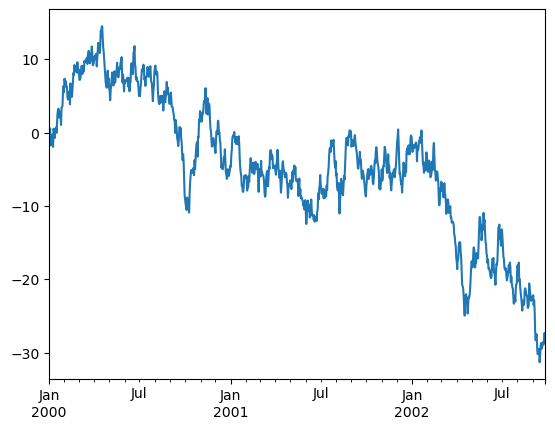

In [90]:
ts = pd.Series(np.random.randn(1000), index=pd.date_range("1/1/2000", periods=1000))
ts = ts.cumsum()
ts.plot();

`plot()` plots all columns of a DataFrame:

<Figure size 640x480 with 0 Axes>

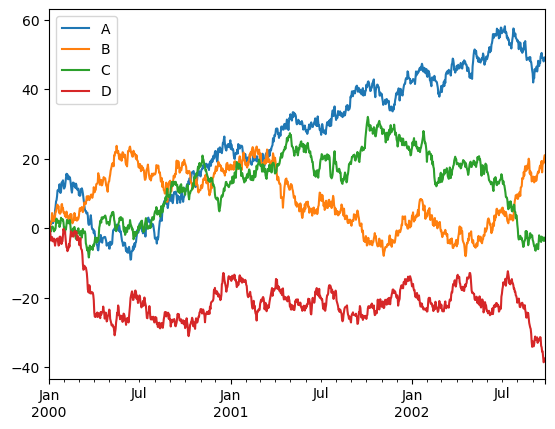

In [91]:
df = pd.DataFrame(
    np.random.randn(1000, 4), index=ts.index, columns=["A", "B", "C", "D"]
)
df = df.cumsum()
plt.figure()
df.plot()
plt.legend(loc="best");

## Importing and exporting data

See the [IO Tools section](https://pandas.pydata.org/pandas-docs/stable/user_guide/io.html).

### CSV

Writing to a CSV file using `DataFrame.to_csv()`:

In [92]:
df = pd.DataFrame(np.random.randint(0, 5, (10, 5)))
df.to_csv("foo.csv")

Reading from a CSV file using `read_csv()`:

In [93]:
pd.read_csv("foo.csv")

,Unnamed: 0,0,1,2,3,4
0,0,0,3,1,1,0
1,1,3,0,0,4,2
2,2,1,0,4,1,2
3,3,4,4,3,3,2
4,4,2,4,2,3,4
5,5,3,2,2,1,2
6,6,4,1,1,1,1
7,7,2,4,3,1,4
8,8,3,3,0,3,2
9,9,1,1,1,1,0


### Parquet

Writing to a Parquet file:

In [94]:
df.to_parquet("foo.parquet")

Reading from a Parquet file using `read_parquet()`:

In [95]:
pd.read_parquet("foo.parquet")

,0,1,2,3,4
0,0,3,1,1,0
1,3,0,0,4,2
2,1,0,4,1,2
3,4,4,3,3,2
4,2,4,2,3,4
5,3,2,2,1,2
6,4,1,1,1,1
7,2,4,3,1,4
8,3,3,0,3,2
9,1,1,1,1,0


### Excel

Writing to an Excel file using `DataFrame.to_excel()`:

In [96]:
df.to_excel("foo.xlsx", sheet_name="Sheet1")

Reading from an Excel file using `read_excel()`:

In [97]:
pd.read_excel("foo.xlsx", "Sheet1", index_col=None, na_values=["NA"])

,Unnamed: 0,0,1,2,3,4
0,0,0,3,1,1,0
1,1,3,0,0,4,2
2,2,1,0,4,1,2
3,3,4,4,3,3,2
4,4,2,4,2,3,4
5,5,3,2,2,1,2
6,6,4,1,1,1,1
7,7,2,4,3,1,4
8,8,3,3,0,3,2
9,9,1,1,1,1,0


## Gotchas

If you are attempting to perform a boolean operation on a `Series` or `DataFrame` you might see an exception like:

```
ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
```

See [Comparisons](https://pandas.pydata.org/pandas-docs/stable/user_guide/basics.html#flexible-comparisons) and [Gotchas](https://pandas.pydata.org/pandas-docs/stable/user_guide/gotchas.html) for an explanation and what to do.

In [98]:
# This will raise a ValueError — included here for illustration
try:
    if pd.Series([False, True, False]):
        print("I was true")
except ValueError as e:
    print(f"ValueError: {e}")

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().
